In [27]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

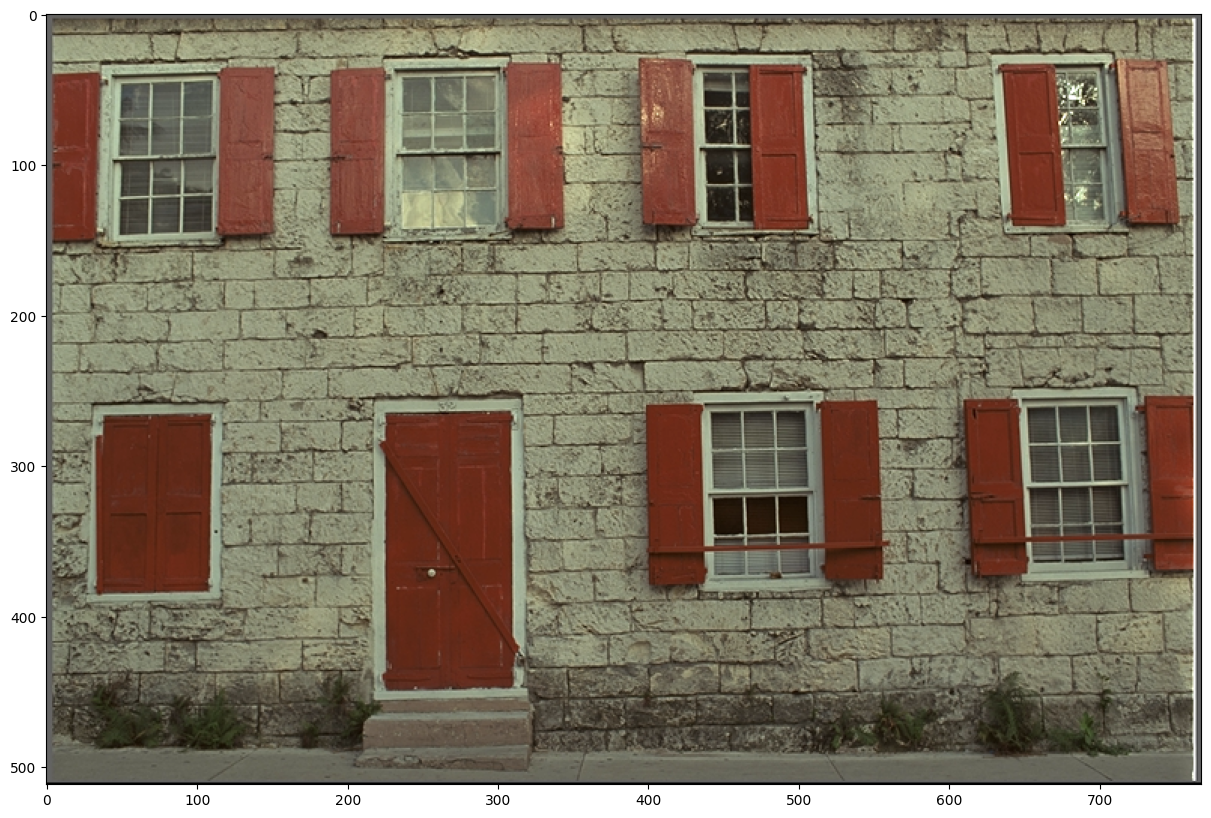

In [29]:
img = cv2.imread('data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [31]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
img_float = img.astype(np.float32)
unsharp = cv2.GaussianBlur(img_float, ksize=(5,5), sigmaX=5, sigmaY=5)

In [33]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img_float - unsharp

(<Axes: title={'center': 'Sharpened (1.5)'}>,
 Text(0.5, 1.0, 'Sharpened (1.5)'))

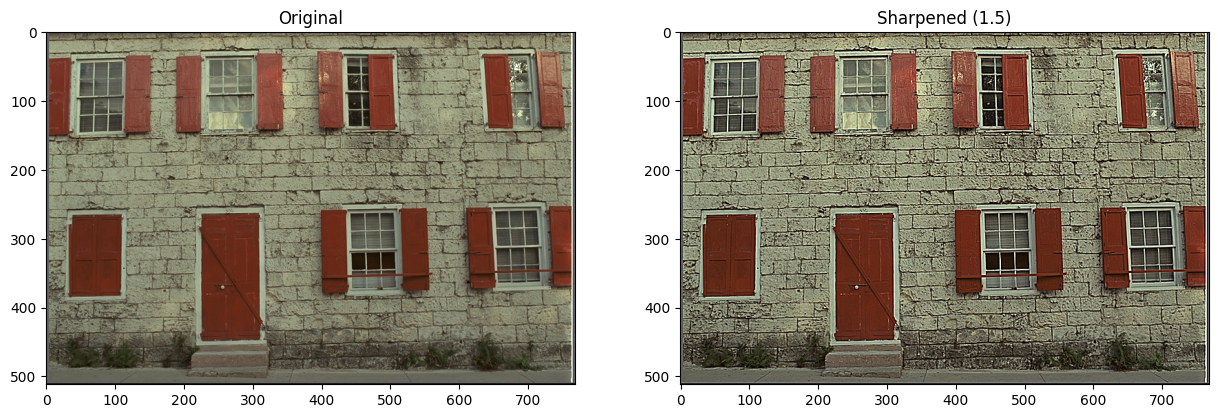

In [35]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
amount = 1.5
sharpened_float = img_float + amount * diff
sharpened = np.clip(sharpened_float, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(sharpened), plt.title('Sharpened (1.5)')

(<Axes: title={'center': 'Sharpened addWeighted'}>,
 Text(0.5, 1.0, 'Sharpened addWeighted'))

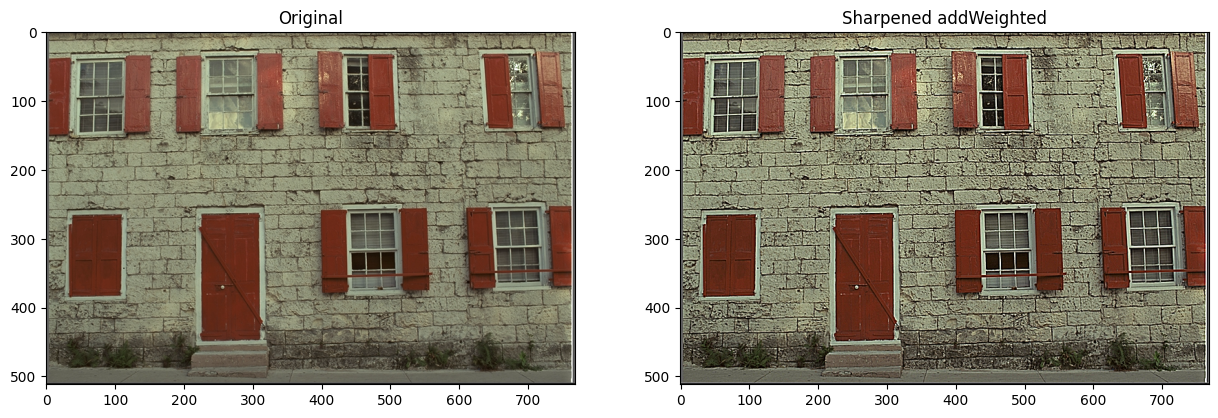

In [39]:
blur = cv2.GaussianBlur(img, ksize=(5,5), sigmaX=5, sigmaY=5)
sharpened2 = cv2.addWeighted(img, 1 + amount, blur, -amount, 0)

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(sharpened2), plt.title('Sharpened addWeighted')

Кращі значення для amount це діапазон значень від 0.5 до 2.0.
При малому значенні (<0.5) amount підсилення різкості зображення буде не помітним, а при великому значенні (>2.0) виникне надмірна різкість малих зображень або зявляться штучні halo_effect навколо контурів